<a href="https://colab.research.google.com/github/pandirib881-alt/Pandiri-Bhanu-Prakash/blob/main/Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Accuracy: 0.00
Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       2.0
    Positive       0.00      0.00      0.00       0.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

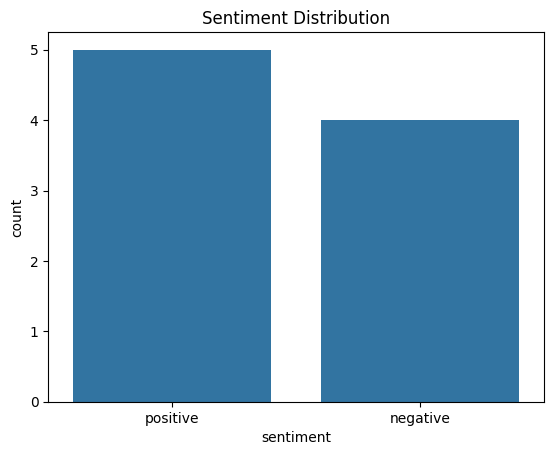

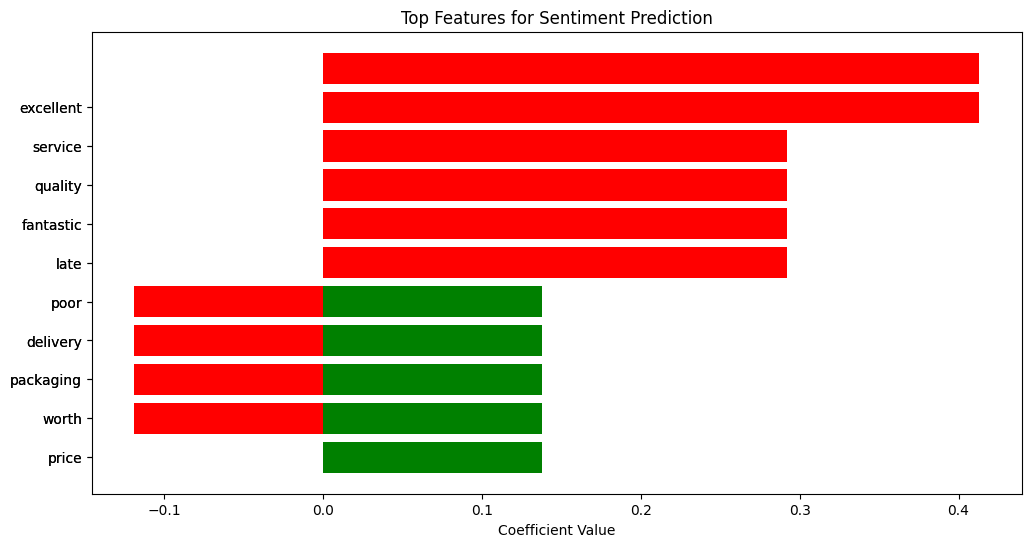

Review: The product broke after one use.
Predicted Sentiment: Positive
Actual Sentiment: Negative
--------------------------------------------------
Review: Terrible experience, will not buy again.
Predicted Sentiment: Positive
Actual Sentiment: Negative
--------------------------------------------------


In [1]:

# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sample dataset of customer reviews
data = {
    'review': [
        'Great product, very satisfied!',
        'Terrible experience, will not buy again.',
        'Average quality, nothing special.',
        'Excellent service and fantastic quality.',
        'Not worth the price.',
        'Loved it! Highly recommended.',
        'Poor packaging and late delivery.',
        'Good value for money.',
        'The product broke after one use.',
        'Satisfied with the purchase.',
    ],
    'sentiment': [
        'positive', 'negative', 'neutral', 'positive', 'negative',
        'positive', 'negative', 'positive', 'negative', 'positive'
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

# Map sentiment labels to binary (positive=1, negative=0), ignoring neutral for simplicity
sentiment_mapping = {'positive': 1, 'negative': 0}
df = df[df['sentiment'].isin(['positive', 'negative'])]  # filter out neutral
df['label'] = df['sentiment'].map(sentiment_mapping)

# Split into features and labels
X = df['review']
y = df['label']

# Split into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Convert text data into TF-IDF features
vectorizer = TfidfVectorizer(stop_words='english', max_features=50)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Initialize and train Logistic Regression classifier
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

# Predict on test data
y_pred = model.predict(X_test_tfidf)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# Visualize sentiment distribution
sns.countplot(x='sentiment', data=df)
plt.title('Sentiment Distribution')
plt.show()

# Visualize top positive and negative features
def plot_top_features(coef, feature_names, top_n=10):
    coef = coef.squeeze()
    top_positive_idx = np.argsort(coef)[-top_n:]
    top_negative_idx = np.argsort(coef)[:top_n]

    plt.figure(figsize=(12,6))
    plt.barh(range(top_n), coef[top_positive_idx], color='green')
    plt.barh(range(top_n, 0, -1), -coef[top_negative_idx], color='red')
    plt.yticks(list(range(top_n)) + list(range(top_n)),
               list(feature_names[top_positive_idx]) + list(feature_names[top_negative_idx]))
    plt.xlabel('Coefficient Value')
    plt.title('Top Features for Sentiment Prediction')
    plt.show()

feature_names = vectorizer.get_feature_names_out()
plot_top_features(model.coef_, feature_names)

# Show some sample predictions
for i in range(min(3, len(X_test))):
    print(f"Review: {X_test.iloc[i]}")
    print(f"Predicted Sentiment: {'Positive' if y_pred[i]==1 else 'Negative'}")
    print(f"Actual Sentiment: {'Positive' if y_test.iloc[i]==1 else 'Negative'}")
    print('-'*50)